In [21]:
import json
import pandas as pd
import numpy as np
import os
import random 
import glob
from tqdm import tqdm

# Set pandas options to display all rows and all columns
# pd.set_option('display.max_rows', None)
# pd.set_option('display.max_columns', None)




In [22]:

df_multiple = pd.read_csv('India data dict - MP_India.csv')
df_multiple.drop(columns = ['total kernels'], inplace=True)
MP_folder = "/media/new_volumn/MP_India_Cleaned1/"

# MP_folder = "/media/new_volumn/MP_India_Cleaned/"

In [23]:
df_multiple.columns

Index(['state', 'city', 'mandi', 'mill', 'breed', 'original location',
       'location', 'image_num', 'date', 'normal kernels'],
      dtype='object')

In [24]:
df_multiple['breed'].unique(), len(df_multiple['breed'].unique())

(array(['Pusa 1509 Basmati', 'Pusa 1121 Basmati', 'Pusa',
        'Pusa 1718 Basmati', 'Pusa 1401 Basmati', 'Sharbati Rice',
        'Sugandha Basmati', 'PB1 Basmati', 'TAJ'], dtype=object),
 9)

In [25]:
df_multiple['folder'] = MP_folder+df_multiple['location'].str.split(' > ').str[-1]

In [26]:
df_multiple[df_multiple['breed'] == 'Pusa 1509 Basmati']['normal kernels'].sum()

np.int64(165797)

In [27]:
def load_npz_file(file_path):
    """Load .npz file and return kernel count."""
    try:
        data = np.load(file_path)
        kernels = data['kernel_pics']  # Assuming the kernels are stored in 'kernel_pics' key
        return kernels.shape[0]  # Return total kernel count
    except Exception as e:
        print(f"Error loading {file_path}: {e}")
        return 0  # Return 0 if file loading fails

def create_balanced_dataset(df):
    # Define breed categories
    main_classes = ['Pusa 1509 Basmati', 'Pusa 1121 Basmati', 'Pusa 1718 Basmati', 'Pusa 1401 Basmati', 'Sugandha Basmati']
    other_classes = ['Pusa', 'Sharbati Rice', 'PB1 Basmati', 'TAJ']

    # Total target kernel count
    total_kernels = 150_000
    main_kernels = 25_000  # Each main class should have 25,000 kernels
    other_kernels_target = 6_250  # 6,250 kernels for "other" classes

    # Filter available classes
    available_classes = df['breed'].unique()
    available_other_classes = [cls for cls in other_classes if cls in available_classes]

    # Ensure at least one "other" class is available
    if not available_other_classes:
        raise ValueError("No 'other' classes are available in the dataset!")

    
    def sample_folders_for_class(df_class, target_kernels, seed=42):
        sampled_df = pd.DataFrame()
        cumulative_kernels = 0
        npz_files = []
        location_files = []

        # Sample folder paths corresponding to the breed class
        unique_folders = df_class['folder'].drop_duplicates().sample(frac=1).tolist()

        for folder in unique_folders:
            folder_rows = df_class[df_class['folder'] == folder]
            # folder_rows.drop
            folder_path = folder_rows['folder'].iloc[0]  # Get the full folder path
            all_npz_files = [f for f in os.listdir(folder_path) if f.endswith('.npz')]  # List all npz files
            random.seed(seed)  # Set seed for reproducibility
            random.shuffle(all_npz_files)

            # Add npz files to the list and update kernel count
            for npz_file in all_npz_files:
                npz_file_path = os.path.join(folder_path, npz_file)
                kernels_in_file = load_npz_file(npz_file_path)
                cumulative_kernels += kernels_in_file
                npz_files.append(npz_file_path)
                location_files.append(npz_file)

                # Add new row with npz file path and kernel count
                new_row = folder_rows.copy()
                new_row['location'] = npz_file_path  # Set location to npz file path
                new_row['location_file'] = npz_file  # Add npz file name to location_file column
                new_row['normal kernels'] = kernels_in_file  # Add kernel count
                sampled_df = pd.concat([sampled_df, new_row], ignore_index=True)

                if cumulative_kernels >= target_kernels:
                    print(f"Maximum kernel count reached for a class")
                    break  # Stop when the target kernel count is reached

            if cumulative_kernels >= target_kernels:
                break  # Stop after reaching the kernel target

        return sampled_df, cumulative_kernels, npz_files

    # Sample main classes (1509 and 1121) and other classes (each 7,000 kernels)
    df_main_1509, used_kernels_1509, npz_files_1509 = sample_folders_for_class(df[df['breed'] == 'Pusa 1509 Basmati'], main_kernels)
    df_main_1121, used_kernels_1121, npz_files_1121 = sample_folders_for_class(df[df['breed'] == 'Pusa 1121 Basmati'], main_kernels)
    df_main_1401, used_kernels_1401, npz_files_1401 = sample_folders_for_class(df[df['breed'] == 'Pusa 1401 Basmati'], main_kernels)
    df_main_1718, used_kernels_1718, npz_files_1718 = sample_folders_for_class(df[df['breed'] == 'Pusa 1718 Basmati'], main_kernels)
    df_main_sugandha, used_kernels_sugandha, npz_files_sugandha = sample_folders_for_class(df[df['breed'] == 'Sugandha Basmati'], main_kernels)

    # Sample "other" classes (7,000 kernels per class)
    df_other_list = []
    used_kernels_other = 0
    for breed in available_other_classes:
        df_class = df[df['breed'] == breed]
        if df_class.empty:
            continue  # Skip if no data for this class
        df_sampled, used_kernels, npz_files = sample_folders_for_class(df_class, other_kernels_target)
        df_other_list.append(df_sampled)
        used_kernels_other += used_kernels

    # Combine all sampled data
    df_balanced = pd.concat([df_main_1509, df_main_1121, df_main_1401, df_main_1718, df_main_sugandha] + df_other_list).reset_index(drop=True)


    # Check final kernel count
    total_kernels_final = df_balanced['normal kernels'].sum()
    print(f"✅ Total Kernels in Dataset: {total_kernels_final} (Target: {total_kernels})")

    return df_balanced

# Usage
df_balanced = create_balanced_dataset(df_multiple)

# Display dataset summary
print(df_balanced.groupby('breed')['normal kernels'].sum())

Maximum kernel count reached for a class
Maximum kernel count reached for a class
Maximum kernel count reached for a class
Maximum kernel count reached for a class
Maximum kernel count reached for a class
Maximum kernel count reached for a class
Maximum kernel count reached for a class
Maximum kernel count reached for a class
✅ Total Kernels in Dataset: 148612 (Target: 150000)
breed
PB1 Basmati           6899
Pusa                  6258
Pusa 1121 Basmati    25146
Pusa 1401 Basmati    25150
Pusa 1509 Basmati    25184
Pusa 1718 Basmati    25055
Sharbati Rice         6581
Sugandha Basmati     22035
TAJ                   6304
Name: normal kernels, dtype: int64


In [11]:
# Ensure unique folders in the final dataset
assert df_balanced['location_file'].nunique() == len(df_balanced['location_file']), "file"

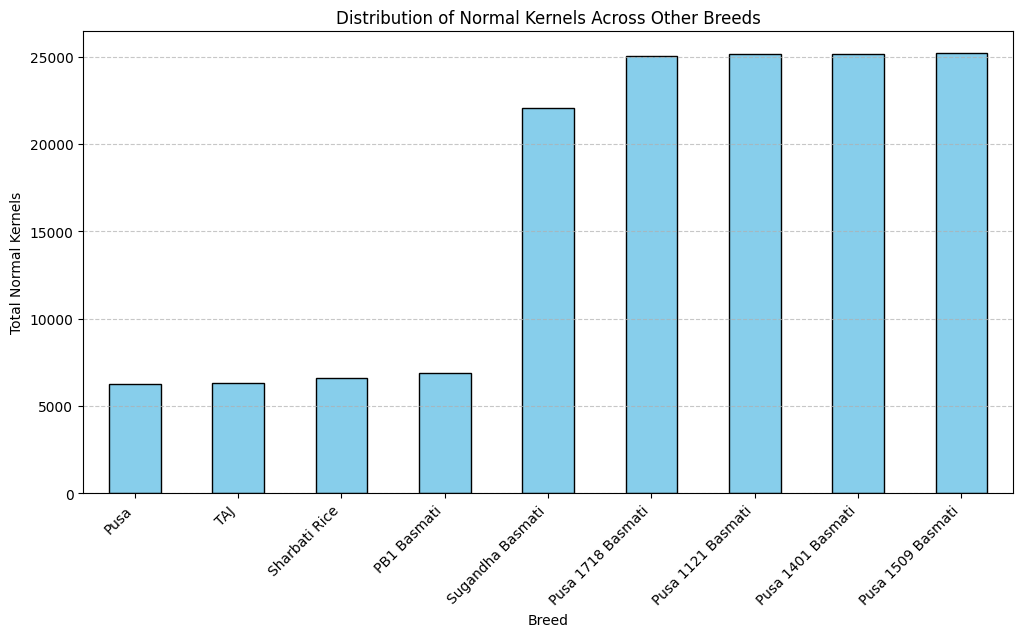

In [28]:
import matplotlib.pyplot as plt

# # Exclude Pusa 1509 Basmati and Pusa 1121 Basmati
# excluded_classes = ['Pusa 1509 Basmati', 'Pusa 1121 Basmati']
# df_plot = df_balanced[~df_balanced['breed'].isin(excluded_classes)]

df_plot = df_balanced

# Group by breed and sum normal kernels
breed_counts = df_plot.groupby('breed')['normal kernels'].sum().sort_values()

# Plot
plt.figure(figsize=(12, 6))
breed_counts.plot(kind='bar', color='skyblue', edgecolor='black')

# Labels and title
plt.xlabel("Breed")
plt.ylabel("Total Normal Kernels")
plt.title("Distribution of Normal Kernels Across Other Breeds")
plt.xticks(rotation=45, ha="right")  # Rotate labels for better readability
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()


In [29]:
df_balanced.to_csv('25-March-MP_India-dataset6Class.csv', index=False)

In [30]:
df_balanced['location_file'][0]

'000005_0000005_1509_SC3180__20241002_0012.npz'

In [31]:
len(df_balanced)

363

In [32]:
from sklearn.model_selection import train_test_split
from collections import Counter
# First, split into train + temp (validation + test) using stratified split

train_df, temp_df = train_test_split(df_balanced, test_size=0.3, stratify=df_balanced['breed'], random_state=42)
val_df, test_df = train_test_split(temp_df, test_size=0.5, stratify=temp_df['breed'], random_state=42)

# Reset indexes
train_df.reset_index(drop=True, inplace=True)
val_df.reset_index(drop=True, inplace=True)
test_df.reset_index(drop=True, inplace=True)

In [33]:
track = "track_6_class-25-March"
os.makedirs(track, exist_ok=True)
train_df.to_csv(f"{track}/train3class.csv", index=False)
test_df.to_csv(f"{track}/test3class.csv", index=False)
val_df.to_csv(f"{track}/val3class.csv", index=False)


In [34]:
train_df = pd.read_csv(f"{track}/train3class.csv")
val_df = pd.read_csv(f"{track}/val3class.csv")
test_df = pd.read_csv(f"{track}/test3class.csv")

In [35]:
from tqdm import tqdm

In [36]:
def create_npz_dataset(df):
    x = []
    y_keys = []
    # Extract columns
    class_names = df["breed"].values
    file_paths = df["location"].values

    # Process images
    x = []
    y_keys = []

    for file_path, class_name in tqdm(zip(file_paths, class_names), desc="Processing images", total=len(file_paths)):
        images = np.load(file_path)['kernel_pics'].astype('uint8')
        y = [class_name] * images.shape[0] # labels
        x.extend(images)
        y_keys.extend(y)

    x = np.array(x)
    y_keys = np.array(y_keys)

    return x, y_keys

In [37]:
X_train, Y_train = create_npz_dataset(train_df)
X_val, Y_val = create_npz_dataset(val_df)
X_test, Y_test = create_npz_dataset(test_df)

Processing images: 100%|██████████| 55/55 [00:07<00:00,  7.10it/s]


In [38]:
PNG_Paddy_6 = "AllPNG_Paddy25-03-2024-6Class"
os.makedirs(PNG_Paddy_6, exist_ok=True)
np.savez_compressed(f"{PNG_Paddy_6}/train_data.npz",x_train=X_train, y_train = Y_train)
np.savez_compressed(f"{PNG_Paddy_6}/val_data.npz",x_val=X_val, y_val=Y_val)
np.savez_compressed(f"{PNG_Paddy_6}/test_data.npz",x_test=X_test, y_test=Y_test)